In [1]:
import pandas as pd

# Load feature-engineered dataset
df = pd.read_csv("../data/processed/feature_engineered_news.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (44680, 18)


,title,text,subject,date,label,content,text_length,word_count,clean_content,title_length,title_word_count,clean_content_length,clean_word_count,title_content_ratio,punctuation_count,number_count,uppercase_count,uppercase_ratio
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...,1118,185,ben stein calls th circuit court committed cou...,89,14,776.0,107.0,0.114543,14,8,114,0.101877
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...,4876,779,trump drops steve bannon national security cou...,55,8,3392.0,435.0,0.016210,100,6,224,0.045930
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...,1913,314,puerto rico expects lift jones act shipping re...,64,10,1230.0,161.0,0.051990,48,0,64,0.033438
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,OOPS: Trump Just Accidentally Confirmed He Le...,1334,195,oops trump just accidentally confirmed leaked ...,89,12,894.0,105.0,0.099441,34,10,74,0.055431
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Donald Trump heads for Scotland to reopen a go...,3193,539,donald trump heads scotland reopen golf resort...,55,10,2142.0,282.0,0.025665,67,24,128,0.040075


In [2]:
# Check dataset information

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nClass Distribution:")
print(df["label"].value_counts())

print("\nMissing Values:")
print(df[["clean_content", "label"]].isnull().sum())

Dataset Shape: (44680, 18)

Columns:
['title', 'text', 'subject', 'date', 'label', 'content', 'text_length', 'word_count', 'clean_content', 'title_length', 'title_word_count', 'clean_content_length', 'clean_word_count', 'title_content_ratio', 'punctuation_count', 'number_count', 'uppercase_count', 'uppercase_ratio']

Class Distribution:
label
0    23469
1    21211
Name: count, dtype: int64

Missing Values:
clean_content    0
label            0
dtype: int64


In [3]:
# Separate input features and target variable

X = df["clean_content"]
y = df["label"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFirst 5 text samples:")
print(X.head())

print("\nFirst 5 labels:")
print(y.head())

Feature shape: (44680,)
Target shape: (44680,)

First 5 text samples:
0    ben stein calls th circuit court committed cou...
1    trump drops steve bannon national security cou...
2    puerto rico expects lift jones act shipping re...
3    oops trump just accidentally confirmed leaked ...
4    donald trump heads scotland reopen golf resort...
Name: clean_content, dtype: object

First 5 labels:
0    0
1    1
2    1
3    0
4    1
Name: label, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (35744,)
Testing feature shape: (8936,)

Training target shape: (35744,)
Testing target shape: (8936,)


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)

# Fit on training data and transform it
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform testing data
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF transformation completed!")

print("\nTraining TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

TF-IDF transformation completed!

Training TF-IDF shape: (35744, 5000)
Testing TF-IDF shape: (8936, 5000)


In [6]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [7]:
# Make predictions on the test data
y_pred_lr = lr_model.predict(X_test_tfidf)

print("Predictions completed successfully!")

# Display first 10 predictions
print("\nFirst 10 predictions:")
print(y_pred_lr[:10])

Predictions completed successfully!

First 10 predictions:
[1 1 1 0 1 1 1 0 0 1]


In [8]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9899283795881826

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4694
           1       0.98      0.99      0.99      4242

    accuracy                           0.99      8936
   macro avg       0.99      0.99      0.99      8936
weighted avg       0.99      0.99      0.99      8936



In [24]:
# Training predictions
y_train_pred_lr = lr_model.predict(X_train_tfidf)

# Training accuracy
train_accuracy_lr = accuracy_score(y_train, y_train_pred_lr)

# Test accuracy (already calculated)
test_accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression")
print("Training Accuracy:", train_accuracy_lr)
print("Test Accuracy:", test_accuracy_lr)

Logistic Regression
Training Accuracy: 0.9937891674127126
Test Accuracy: 0.9899283795881826


Confusion Matrix:
[[4629   65]
 [  25 4217]]


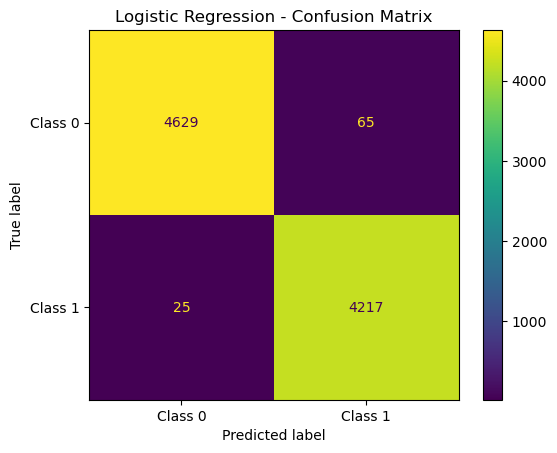

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [10]:
# ==========================================
# MULTINOMIAL NAIVE BAYES MODEL
# ==========================================

from sklearn.naive_bayes import MultinomialNB

# Initialize the model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [11]:
# ==========================================
# NAIVE BAYES PREDICTIONS
# ==========================================

# Make predictions on the test data
y_pred_nb = nb_model.predict(X_test_tfidf)

print("Predictions completed successfully!")

# Display first 10 predictions
print("\nFirst 10 predictions:")
print(y_pred_nb[:10])

Predictions completed successfully!

First 10 predictions:
[1 1 1 0 1 1 1 0 0 1]


In [12]:
# ==========================================
# NAIVE BAYES MODEL EVALUATION
# ==========================================

from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9458370635631155

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      4694
           1       0.94      0.95      0.94      4242

    accuracy                           0.95      8936
   macro avg       0.95      0.95      0.95      8936
weighted avg       0.95      0.95      0.95      8936



In [25]:
# Training predictions
y_train_pred_nb = nb_model.predict(X_train_tfidf)

# Training accuracy
train_accuracy_nb = accuracy_score(y_train, y_train_pred_nb)

# Test accuracy
test_accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes")
print("Training Accuracy:", train_accuracy_nb)
print("Test Accuracy:", test_accuracy_nb)

Naive Bayes
Training Accuracy: 0.9498936884512086
Test Accuracy: 0.9458370635631155


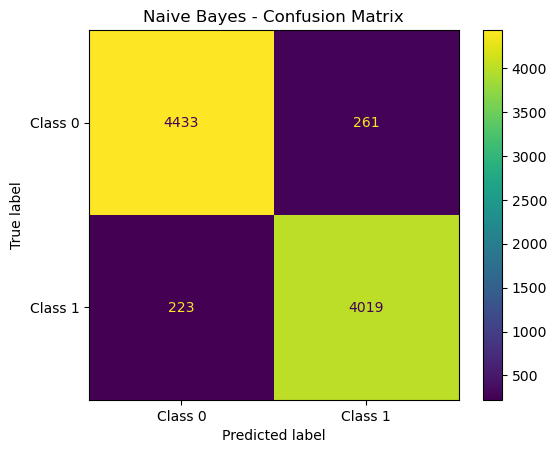

In [13]:
# ==========================================
# NAIVE BAYES CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()

plt.title("Naive Bayes - Confusion Matrix")
plt.show()

In [14]:
import pandas as pd

# Create model comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_nb
    ]
})

# Convert accuracy to percentage
model_comparison["Accuracy (%)"] = (
    model_comparison["Accuracy"] * 100
).round(2)

# Remove decimal accuracy column
model_comparison = model_comparison.drop(columns=["Accuracy"])

print("MODEL COMPARISON")
print(model_comparison)

MODEL COMPARISON
                     Model  Accuracy (%)
0      Logistic Regression         98.99
1  Multinomial Naive Bayes         94.58


In [15]:
# ============================================
# DECISION TREE CLASSIFIER
# ============================================

from sklearn.tree import DecisionTreeClassifier

# Initialize the model
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [17]:
# ==========================================
# DECISION TREE CLASSIFIER
# ==========================================

from sklearn.tree import DecisionTreeClassifier

# Initialize the model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train_tfidf, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [18]:
# ==========================================
# MAKE PREDICTIONS - DECISION TREE
# ==========================================

y_pred_dt = dt_model.predict(X_test_tfidf)

print("Decision Tree predictions completed successfully!")

print("\nFirst 10 predictions:")
print(y_pred_dt[:10])

Decision Tree predictions completed successfully!

First 10 predictions:
[1 1 1 0 1 1 1 0 0 1]


In [19]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9941808415398389

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4694
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8936
   macro avg       0.99      0.99      0.99      8936
weighted avg       0.99      0.99      0.99      8936



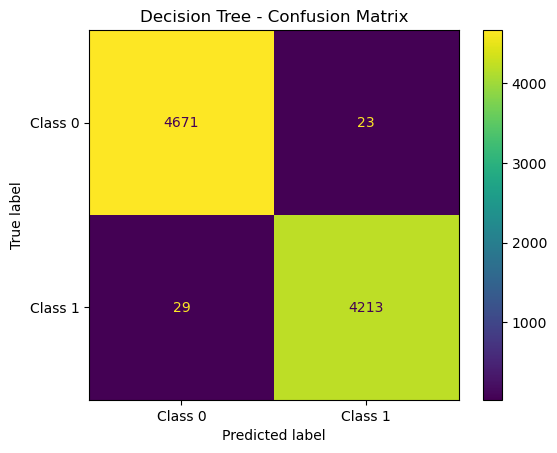

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Class 0", "Class 1"]
)

disp.plot(cmap="viridis")

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [26]:
# Training predictions
y_train_pred_dt = dt_model.predict(X_train_tfidf)

# Training accuracy
train_accuracy_dt = accuracy_score(y_train, y_train_pred_dt)

# Test accuracy
test_accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree")
print("Training Accuracy:", train_accuracy_dt)
print("Test Accuracy:", test_accuracy_dt)

Decision Tree
Training Accuracy: 1.0
Test Accuracy: 0.9941808415398389


In [21]:
from sklearn.tree import DecisionTreeClassifier

# ==========================================
# PRE-PRUNED DECISION TREE
# ==========================================

dt_prepruned = DecisionTreeClassifier(
    max_depth=30,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train the model
dt_prepruned.fit(X_train_tfidf, y_train)

print("Pre-Pruned Decision Tree trained successfully!")

Pre-Pruned Decision Tree trained successfully!


In [22]:
# ==========================================
# PREDICTIONS - PRE-PRUNED DECISION TREE
# ==========================================

y_pred_pre = dt_prepruned.predict(X_test_tfidf)

print("Pre-Pruned Decision Tree predictions completed!")
print("\nFirst 10 predictions:")
print(y_pred_pre[:10])

Pre-Pruned Decision Tree predictions completed!

First 10 predictions:
[1 1 1 0 1 1 1 0 0 1]


In [23]:
# ==========================================
# EVALUATION - PRE-PRUNED DECISION TREE
# ==========================================

from sklearn.metrics import accuracy_score, classification_report

accuracy_pre = accuracy_score(y_test, y_pred_pre)

print("Pre-Pruned Decision Tree Accuracy:", accuracy_pre)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_pre))

Pre-Pruned Decision Tree Accuracy: 0.9944046553267681

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4694
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8936
   macro avg       0.99      0.99      0.99      8936
weighted avg       0.99      0.99      0.99      8936



In [27]:
# ==========================================
# TRAINING vs TEST ACCURACY - PRE-PRUNED DT
# ==========================================

# Training predictions
y_train_pred_pre = dt_prepruned.predict(X_train_tfidf)

# Training accuracy
train_accuracy_pre = accuracy_score(
    y_train,
    y_train_pred_pre
)

# Test accuracy
test_accuracy_pre = accuracy_score(
    y_test,
    y_pred_pre
)

print("Pre-Pruned Decision Tree")
print("Training Accuracy:", train_accuracy_pre)
print("Test Accuracy:", test_accuracy_pre)

# Accuracy gap
print("Accuracy Gap:",
      train_accuracy_pre - test_accuracy_pre)

Pre-Pruned Decision Tree
Training Accuracy: 0.9971463742166518
Test Accuracy: 0.9944046553267681
Accuracy Gap: 0.0027417188898836153


In [28]:
from sklearn.tree import DecisionTreeClassifier

# Create a temporary decision tree
dt_temp = DecisionTreeClassifier(random_state=42)

# Get cost complexity pruning path
path = dt_temp.cost_complexity_pruning_path(
    X_train_tfidf,
    y_train
)

# Get alpha values
ccp_alphas = path.ccp_alphas

print("Number of alpha values:", len(ccp_alphas))
print("\nFirst 10 alpha values:")
print(ccp_alphas[:10])

Number of alpha values: 54

First 10 alpha values:
[0.00000000e+00 2.79601522e-05 2.79767234e-05 2.79767234e-05
 2.79767234e-05 2.79767234e-05 2.79767234e-05 2.79767234e-05
 3.35599983e-05 3.49039532e-05]


In [29]:
import numpy as np

# Select a reasonable number of alpha values
alpha_values = np.linspace(
    ccp_alphas[0],
    ccp_alphas[-2],
    20
)

train_scores = []
test_scores = []

for alpha in alpha_values:

    # Create post-pruned tree
    dt_post = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )

    # Train model
    dt_post.fit(X_train_tfidf, y_train)

    # Calculate training accuracy
    train_score = dt_post.score(X_train_tfidf, y_train)

    # Calculate test accuracy
    test_score = dt_post.score(X_test_tfidf, y_test)

    train_scores.append(train_score)
    test_scores.append(test_score)

print("Post-pruning models trained successfully!")

Post-pruning models trained successfully!


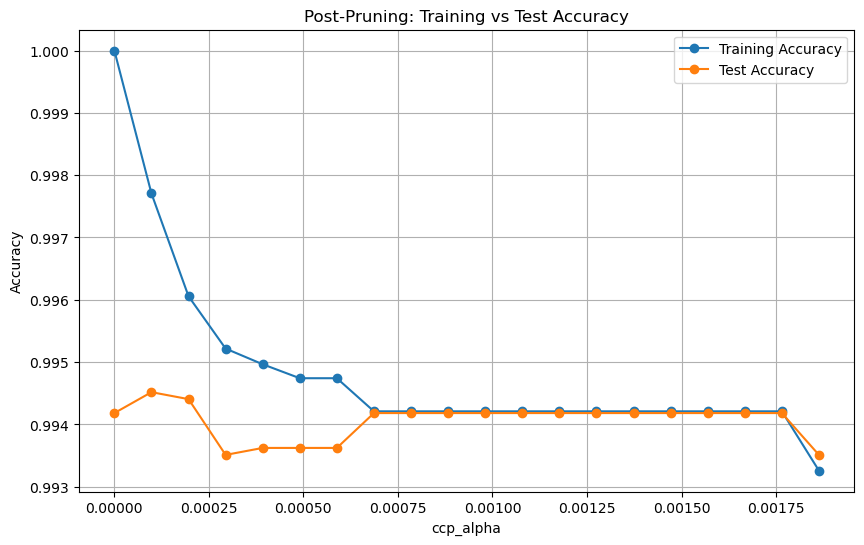

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    alpha_values,
    train_scores,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    alpha_values,
    test_scores,
    marker='o',
    label='Test Accuracy'
)

plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Post-Pruning: Training vs Test Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [31]:
import numpy as np

best_index = np.argmax(test_scores)

best_alpha = alpha_values[best_index]

print("Best index:", best_index)
print("Best ccp_alpha:", best_alpha)
print("Best Training Accuracy:", train_scores[best_index])
print("Best Test Accuracy:", test_scores[best_index])

Best index: 1
Best ccp_alpha: 9.807646798052991e-05
Best Training Accuracy: 0.9977059086839749
Best Test Accuracy: 0.9945165622202328


In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create final post-pruned model
dt_post_final = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)

# Train the model
dt_post_final.fit(X_train_tfidf, y_train)

# Predictions
y_train_pred_post = dt_post_final.predict(X_train_tfidf)
y_test_pred_post = dt_post_final.predict(X_test_tfidf)

# Calculate accuracy
train_accuracy_post = accuracy_score(
    y_train,
    y_train_pred_post
)

test_accuracy_post = accuracy_score(
    y_test,
    y_test_pred_post
)

# Calculate accuracy gap
accuracy_gap_post = train_accuracy_post - test_accuracy_post

print("POST-PRUNED DECISION TREE")
print("=" * 35)

print("Best CCP Alpha:", best_alpha)
print("Training Accuracy:", train_accuracy_post)
print("Test Accuracy:", test_accuracy_post)
print("Accuracy Gap:", accuracy_gap_post)

POST-PRUNED DECISION TREE
Best CCP Alpha: 9.807646798052991e-05
Training Accuracy: 0.9977059086839749
Test Accuracy: 0.9945165622202328
Accuracy Gap: 0.0031893464637421376


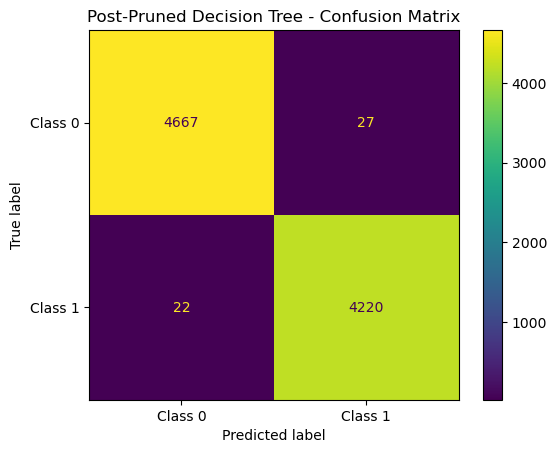

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm_post = confusion_matrix(
    y_test,
    y_test_pred_post
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_post,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()

plt.title("Post-Pruned Decision Tree - Confusion Matrix")

plt.show()

In [34]:
import pandas as pd

comparison_dt = pd.DataFrame({
    "Model": [
        "Original Decision Tree",
        "Pre-Pruned Decision Tree",
        "Post-Pruned Decision Tree"
    ],
    
    "Training Accuracy": [
        train_accuracy_dt,
        train_accuracy_pre,
        train_accuracy_post
    ],
    
    "Test Accuracy": [
        test_accuracy_dt,
        test_accuracy_pre,
        test_accuracy_post
    ]
})

comparison_dt

,Model,Training Accuracy,Test Accuracy
0,Original Decision Tree,1.000000,0.994181
1,Pre-Pruned Decision Tree,0.997146,0.994405
2,Post-Pruned Decision Tree,0.997706,0.994517


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [36]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [37]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [38]:
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search_rf.fit(X_train_tfidf, y_train)

print("Best Parameters:")
print(grid_search_rf.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search_rf.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation Accuracy:
0.9974541330413541


In [39]:
best_rf_model = grid_search_rf.best_estimator_

print("Best Random Forest model selected successfully!")

Best Random Forest model selected successfully!


In [40]:
from sklearn.metrics import accuracy_score

# Training predictions
y_train_pred_rf = best_rf_model.predict(X_train_tfidf)

# Test predictions
y_test_pred_rf = best_rf_model.predict(X_test_tfidf)

# Calculate accuracies
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print("Random Forest Results")
print("----------------------")
print("Training Accuracy:", train_accuracy_rf)
print("Test Accuracy:", test_accuracy_rf)
print("Accuracy Gap:", train_accuracy_rf - test_accuracy_rf)

Random Forest Results
----------------------
Training Accuracy: 1.0
Test Accuracy: 0.9979856759176365
Accuracy Gap: 0.002014324082363461


In [41]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report:\n")

print(classification_report(
    y_test,
    y_test_pred_rf
))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4694
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8936
   macro avg       1.00      1.00      1.00      8936
weighted avg       1.00      1.00      1.00      8936



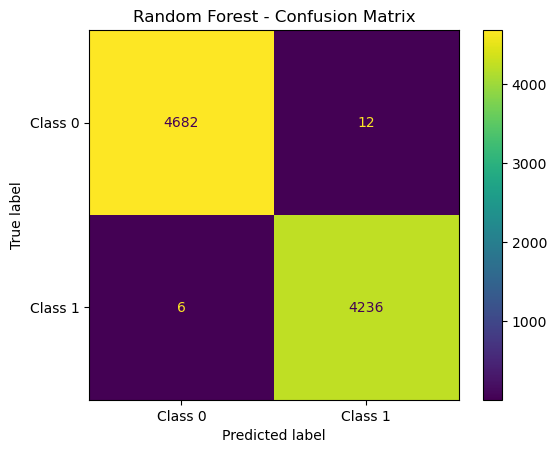

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")

plt.show()

In [43]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [44]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [45]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

In [46]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

In [47]:
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_train_tfidf, y_train)

print("Best Parameters:")
print(grid_search_xgb.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search_xgb.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
18 fits failed out of a total of 48.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py", line 569, in inner_f
    return func(**kwargs)
  File "C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\xgboost\sklearn.py", line 1857, in fit
    self._Booster = tra

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}

Best Cross-Validation Accuracy:
0.9970344751457342
